In [1]:
import numpy as np
import matplotlib.pyplot as plt

****
## Problem 2

In [2]:
A = np.load('dataset1')

In [3]:
x = A[:,0]
y = A[:,1]

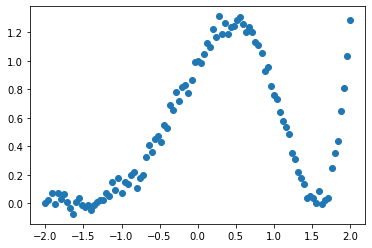

In [4]:
plt.scatter(x,y)

In [5]:
m = len(x)

deg = 9
B = np.zeros((m,deg+1))
for i in range(deg+1):
    B[:,i] = x**i
coeffs = np.linalg.lstsq(B,y,rcond=None)[0]

In [6]:
m_plot = 200
x_plot = np.linspace(-2,2,m_plot)
A_plot = np.zeros((m_plot,deg+1))
for i in range(deg+1):
    A_plot[:,i] = x_plot**i
y_plot = A_plot.dot(coeffs)

(-0.5, 1.5)

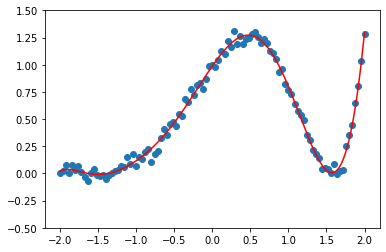

In [7]:
plt.scatter(x,y)
plt.plot(x_plot,y_plot,color='red')
plt.ylim([-0.5,1.5])

****
## Problem 3

In [8]:
A = np.load('dataset2')

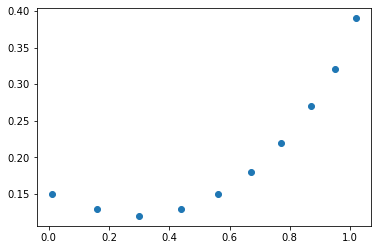

In [9]:
s = A[:,0]
t = A[:,1]
plt.scatter(s,t)

In [10]:
m = len(s)

B = np.zeros((m,5))

B[:,0] = s**2
B[:,1] = s*t
B[:,2] = t**2
B[:,3] = s
B[:,4] = t

one = np.ones(m)

coeffs = np.linalg.lstsq(B,one, rcond=None)[0]


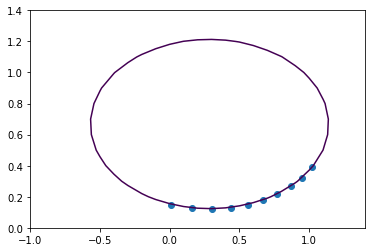

In [25]:
x = np.arange(-1,1.5,0.1)
y = np.arange(0,1.5,0.1)

xx,yy= np.meshgrid(x,y)

zz = coeffs[0]*xx**2+coeffs[1]*xx*yy+coeffs[2]*yy**2+coeffs[3]*xx+coeffs[4]*yy

plt.contour(xx,yy,zz,levels=[1])

plt.scatter(s,t)

****
## Problem 7


In [12]:
def plane_reflector(x,j):
    Q = np.eye(len(x))
    Q[0,0] = x[j]/np.sqrt(x[0]**2+x[j]**2)
    Q[j,j] = Q[0,0]
    
    Q[0,j] = -x[0]/np.sqrt(x[0]**2+x[j]**2)
    Q[j,0] = - Q[0,j]
    
    return Q

In [13]:
def rotate_to_x1(x):
    'Finds Q that rotates an n by 1 vector x so that its norm is in its first entry and all other entries are 0'
    
    n = len(x)
    Q = np.eye(n)
    
    for i in range(1,n):
        Q = plane_reflector(x,i).dot(Q)
    return Q

In [14]:
def qr_rotators(A):
    'it factors a full-column rank A into complete Q (orthogonal) times R (upper triangular) using plane rotators'
    m,n = A.shape
    
    R = A.copy()
    Q = np.eye(m)
    
    for j in range(n):
        x = R[j:m,j].copy()
        rotator = rotate_to_x1(x)
        
        # apply reflector to R
        R[j:m,j:n] = rotator.dot(R[j:m,:n])
        # apply reflector to P
        Q[j:m,:] = rotator.dot(Q[j:m,:])
        
        return Q.T, np.triu(R),

In [15]:
A = np.random.randn(5,5)

In [16]:
A

array([[ 4.60685789e-01, -9.74225470e-01,  9.73718736e-01,
         1.46429475e+00,  5.34644352e-01],
       [ 2.04060875e-01, -3.31026100e-03,  9.94652834e-01,
        -1.18140660e+00, -5.02370138e-01],
       [-1.09423771e+00, -4.19948813e-04,  2.41001513e-01,
        -2.23284210e-01, -5.42382976e-01],
       [ 9.16922215e-01, -1.63772743e+00, -6.66248759e-02,
        -1.22223395e-01,  9.55040721e-01],
       [ 6.25482603e-01,  1.17268178e+00,  2.41021004e+00,
         7.32096392e-01,  1.39612377e-01]])

In [17]:
Q,R = qr_rotators(A)

In [18]:
R

array([[-0.39690274,  0.15630909, -1.13099027, -1.43715408, -0.7247667 ],
       [ 0.        , -0.89209241,  1.29312017,  0.86036437,  0.28537633],
       [ 0.        ,  0.        , -0.42198056,  0.85503821,  0.76213512],
       [ 0.        ,  0.        ,  0.        , -0.76264691,  0.66821902],
       [ 0.        ,  0.        ,  0.        ,  0.        , -0.36041783]])

In [19]:
np.round(Q.dot(Q.T))

array([[ 1.,  0., -0., -0.,  0.],
       [ 0.,  1., -0.,  0., -0.],
       [-0., -0.,  1., -0.,  0.],
       [-0.,  0., -0.,  1.,  0.],
       [ 0., -0.,  0.,  0.,  1.]])

In [20]:
Q.dot(Q.T)

array([[ 1.00000000e+00,  1.38777878e-17, -6.93889390e-18,
        -2.08166817e-17,  0.00000000e+00],
       [ 1.38777878e-17,  1.00000000e+00, -2.77555756e-17,
         4.16333634e-17, -5.55111512e-17],
       [-6.93889390e-18, -2.77555756e-17,  1.00000000e+00,
        -6.93889390e-18,  0.00000000e+00],
       [-2.08166817e-17,  4.16333634e-17, -6.93889390e-18,
         1.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00, -5.55111512e-17,  0.00000000e+00,
         0.00000000e+00,  1.00000000e+00]])